In [3]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [4]:
X, y = make_regression(n_features=1, n_informative=1, n_samples=100, n_targets=1, noise=20, random_state=23)

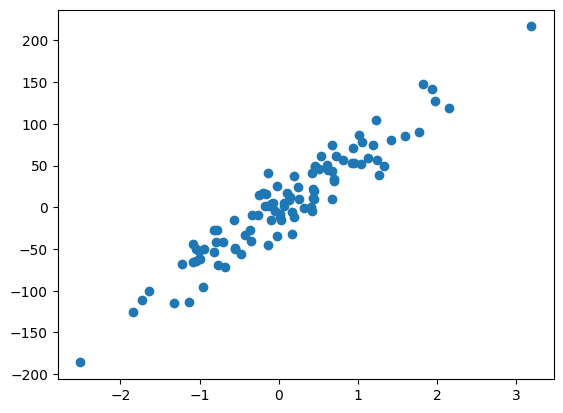

In [6]:
plt.scatter(X, y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(X_test)
print(lr.coef_)
print(lr.intercept_)

[61.98986086]
-0.8197871129038203


C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1351: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.592e+04, tolerance: 2.801e+01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers i

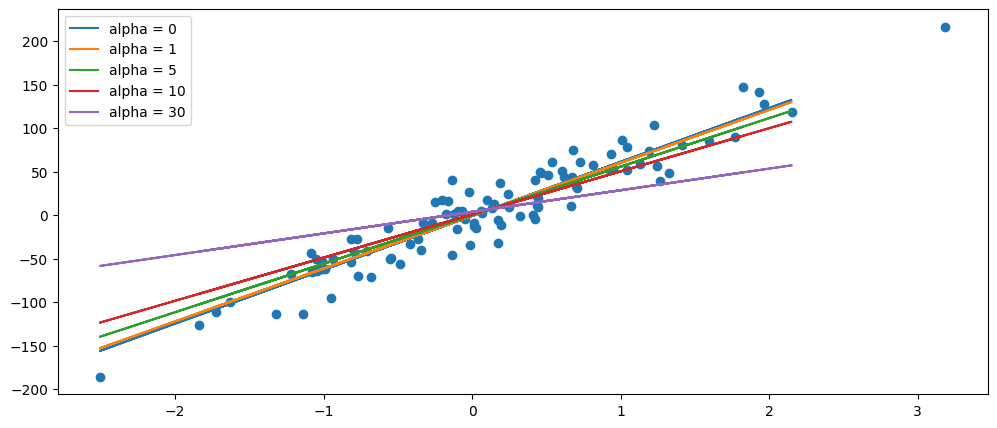

In [13]:
alphas = [0, 1, 5, 10, 30]
plt.figure(figsize=(12, 5))
plt.scatter(X, y)

for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train, y_train)
    plt.plot(X_test, L.predict(X_test), label= "alpha = {}".format(i))
plt.legend()
plt.show()

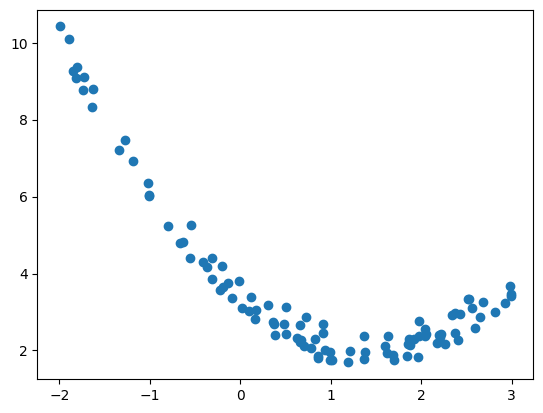

In [22]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.rand(m , 1)

plt.scatter(x1, x2)
plt.show()

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1351: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.399e+00, tolerance: 4.625e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers i

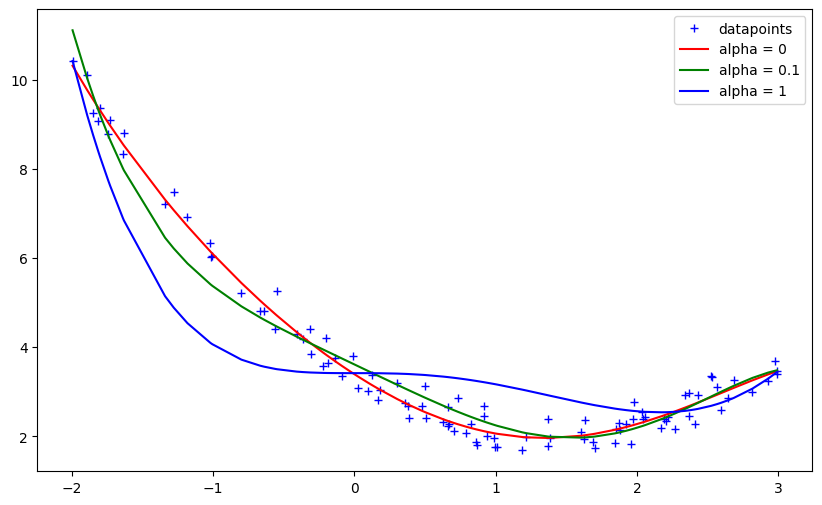

In [30]:
def get_pred_lasso(x1, x2, alpha):
    model = Pipeline([
        ("Poly_features", PolynomialFeatures(degree=5)),
        ("lasso", Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ["r", "g", "b"]
plt.figure(figsize=(10, 6))
plt.plot(x1, x2, "b+", label = "datapoints")

for alpha, c in zip(alphas, cs):
    pred = get_pred_lasso(x1, x2, alpha)
    plt.plot(sorted(x1[:,0]), pred[np.argsort(x1[:, 0])], c, label= "alpha = {}".format(alpha))

plt.legend()
plt.show()